<a href="https://colab.research.google.com/github/Nachos-mic/Lung_CT_Diagnostic_ML/blob/main/Lung_Diagnostics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Biblioteki


In [ ]:
!pip install -q grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 67.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from PIL import Image
from google.colab import drive
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
import time
import copy
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import random

Rozpakowanie danych do dysku (jednorazowe)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

#Tworzenie folderu z danymi
!mkdir -p /content/dataset
!unzip -q "/content/drive/MyDrive/lung_dataset.zip" -d "/content/dataset"
print("Dane rozpakowane pomyślnie!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
replace /content/dataset/data_2d_full_slices/LUNG1-001_slice_0060.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
Dane rozpakowane pomyślnie!


EDA dla datasetu - statystyki klas i wizualizacja przykładowych slice'ów

/tmp/ipykernel_7600/688474938.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_train, x='original_stage', order=['I', 'II', 'IIIa', 'IIIb'], palette='viridis')


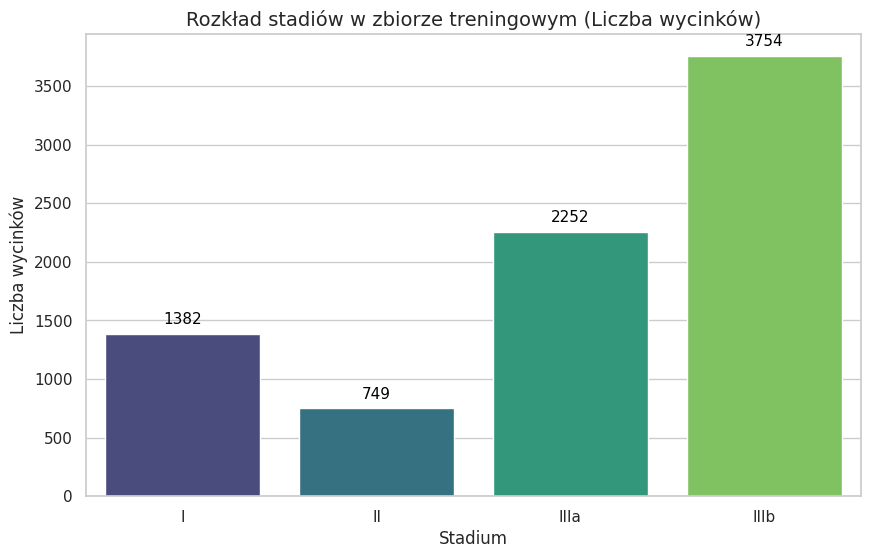


--- Przykładowe wycinki dla poszczególnych klas ---


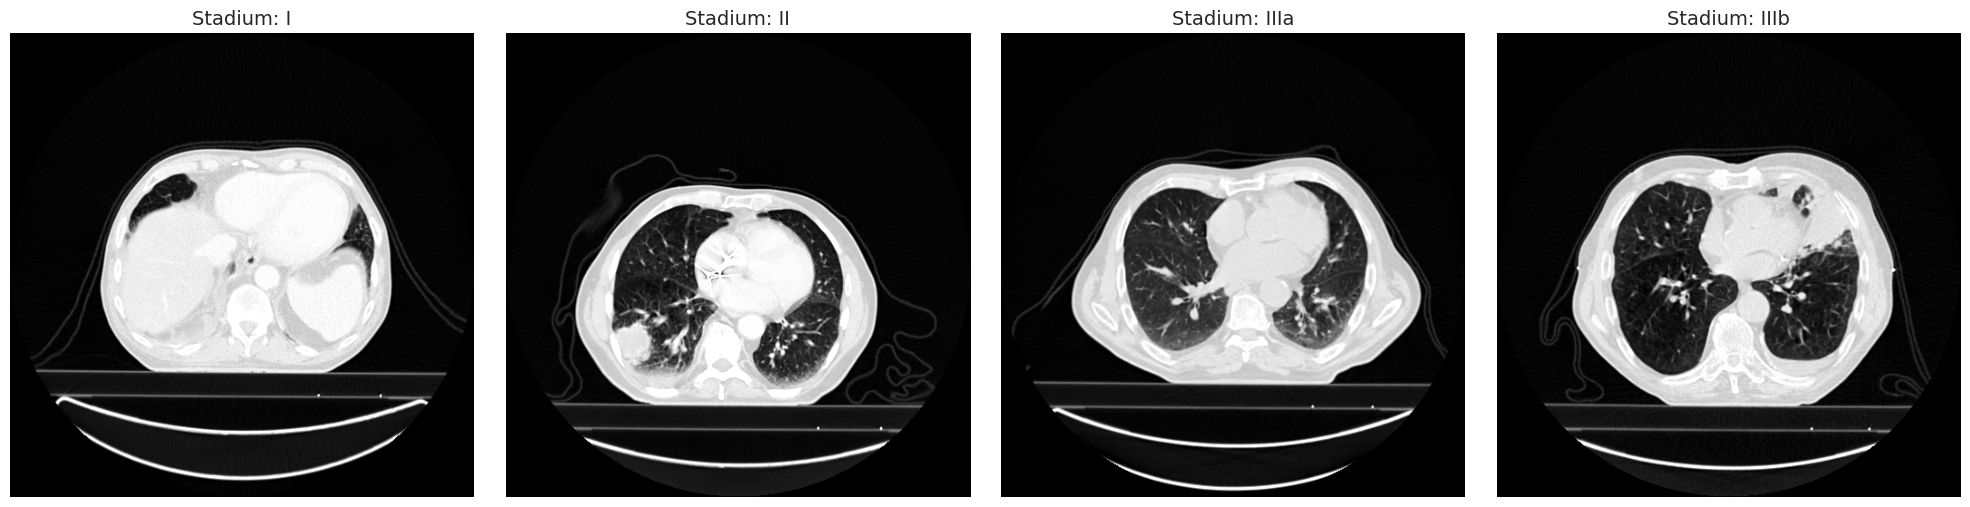

In [ ]:
# Ścieżka do wypakowanego pliku train.csv
TRAIN_CSV = '/content/dataset/train.csv'

df_train = pd.read_csv(TRAIN_CSV)

# 1. Statystyki klas w zbiorze treningowym
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df_train, x='original_stage', order=['I', 'II', 'IIIa', 'IIIb'], palette='viridis')
plt.title('Rozkład stadiów w zbiorze treningowym (Liczba wycinków)', fontsize=14)
plt.xlabel('Stadium', fontsize=12)
plt.ylabel('Liczba wycinków', fontsize=12)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, color='black', xytext=(0, 5), textcoords='offset points')
plt.show()

# 2. Wizualizacja przykładowych zdjęć dla każdej z 4 klas
print("\n--- Przykładowe wycinki dla poszczególnych klas ---")
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
stages = ['I', 'II', 'IIIa', 'IIIb']

for i, stage in enumerate(stages):
    sample_img_path = df_train[df_train['original_stage'] == stage].iloc[0]['image_path']

    clean_path = sample_img_path.replace('\\', '/')
    filename = os.path.basename(clean_path)

    colab_img_path = os.path.join('/content/dataset/data_2d_full_slices', filename)

    img = Image.open(colab_img_path)
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"Stadium: {stage}", fontsize=14)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

EDA dla datasetu - demografia pacjentów, typy histologiczne i podział slice'ów pomiędzy pacjentami

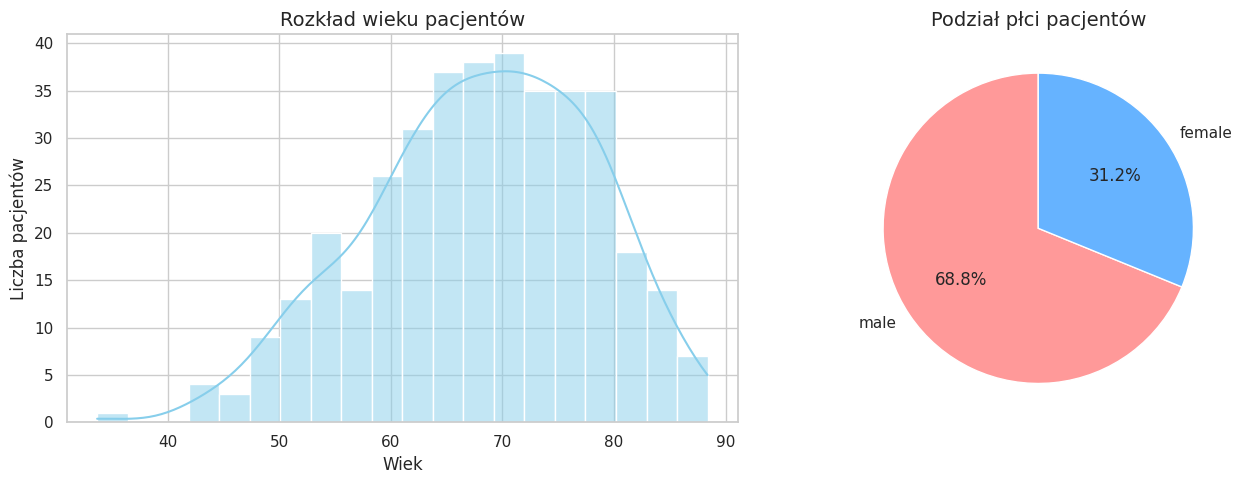

/tmp/ipykernel_7600/3080178802.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_merged, y=histology_col, order=df_merged[histology_col].value_counts().index, palette='pastel')


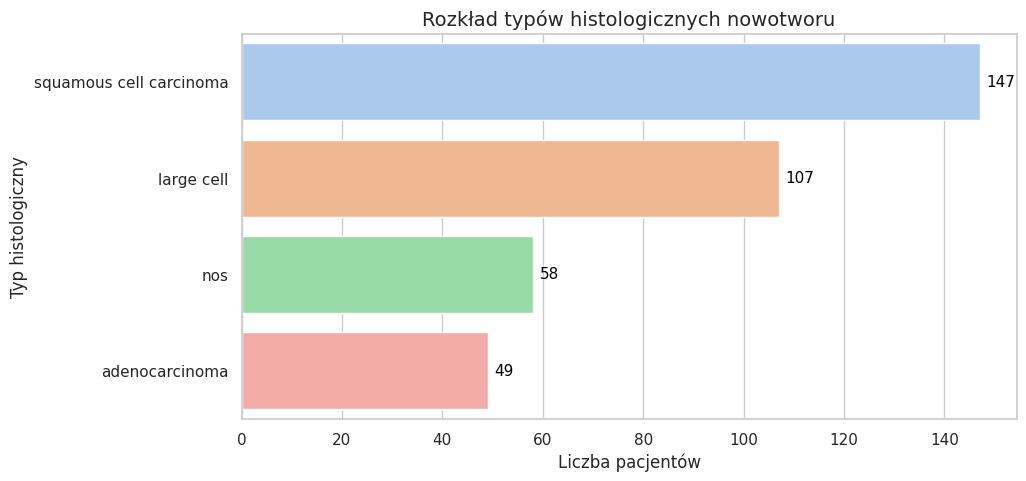

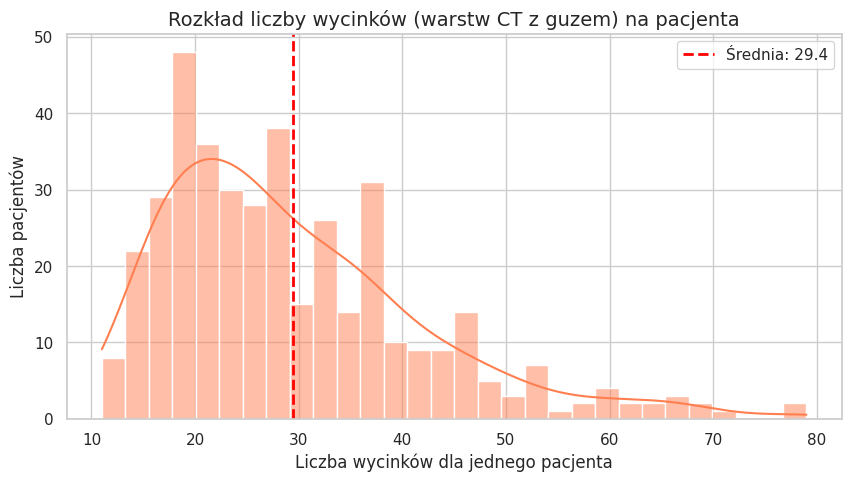

Całkowita liczba uwzględnionych pacjentów: 401
Średni wiek pacjenta: 68.1 lat (Min: 34, Max: 88)
Średnia liczba wycinków na pacjenta: 29.4
Pacjent z najmniejszą liczbą wycinków ma ich: 11
Pacjent z największą liczbą wycinków ma ich: 79


In [ ]:

MASTER_CSV = r"/content/dataset/master_dataset.csv"
CLINICAL_CSV = r"/content/dataset/NSCLC-Radiomics-Lung1.clinical-data.csv"

df_master = pd.read_csv(MASTER_CSV)
df_clinical = pd.read_csv(CLINICAL_CSV)

df_clinical['PatientID'] = df_clinical['PatientID'].astype(str).str.strip()
df_master['patient_id'] = df_master['patient_id'].astype(str).str.strip()

df_merged = df_master[['patient_id']].drop_duplicates().merge(
    df_clinical, left_on='patient_id', right_on='PatientID', how='inner'
)

sns.set_theme(style="whitegrid")

# WYKRES 1: Demografia (Wiek i Płeć)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


sns.histplot(data=df_merged, x='age', bins=20, kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Rozkład wieku pacjentów', fontsize=14)
axes[0].set_xlabel('Wiek', fontsize=12)
axes[0].set_ylabel('Liczba pacjentów', fontsize=12)

gender_col = 'gender' if 'gender' in df_merged.columns else 'Gender' if 'Gender' in df_merged.columns else None

if gender_col:
    gender_counts = df_merged[gender_col].value_counts()
    axes[1].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
                startangle=90, colors=['#ff9999','#66b3ff'])
    axes[1].set_title('Podział płci pacjentów', fontsize=14)

plt.tight_layout()
plt.show()

# WYKRES 2: Typy Histologiczne
histology_col = 'Histology' if 'Histology' in df_merged.columns else 'histology' if 'histology' in df_merged.columns else None

if histology_col:
    plt.figure(figsize=(10, 5))
    ax = sns.countplot(data=df_merged, y=histology_col, order=df_merged[histology_col].value_counts().index, palette='pastel')
    plt.title('Rozkład typów histologicznych nowotworu', fontsize=14)
    plt.xlabel('Liczba pacjentów', fontsize=12)
    plt.ylabel('Typ histologiczny', fontsize=12)

    for p in ax.patches:
        ax.annotate(f'{int(p.get_width())}', (p.get_width(), p.get_y() + p.get_height() / 2.),
                    ha='left', va='center', fontsize=11, color='black', xytext=(5, 0), textcoords='offset points')
    plt.show()

# WYKRES 3: Rozkład liczby warstw (wycinków) na pacjenta
plt.figure(figsize=(10, 5))
slices_per_patient = df_master.groupby('patient_id').size()

sns.histplot(slices_per_patient, bins=30, kde=True, color='coral')
plt.title('Rozkład liczby wycinków (warstw CT z guzem) na pacjenta', fontsize=14)
plt.xlabel('Liczba wycinków dla jednego pacjenta', fontsize=12)
plt.ylabel('Liczba pacjentów', fontsize=12)

mean_slices = slices_per_patient.mean()
plt.axvline(mean_slices, color='red', linestyle='dashed', linewidth=2, label=f'Średnia: {mean_slices:.1f}')
plt.legend()
plt.show()

print(f"Całkowita liczba uwzględnionych pacjentów: {len(df_merged)}")
print(f"Średni wiek pacjenta: {df_merged['age'].mean():.1f} lat (Min: {df_merged['age'].min():.0f}, Max: {df_merged['age'].max():.0f})")
print(f"Średnia liczba wycinków na pacjenta: {mean_slices:.1f}")
print(f"Pacjent z najmniejszą liczbą wycinków ma ich: {slices_per_patient.min()}")
print(f"Pacjent z największą liczbą wycinków ma ich: {slices_per_patient.max()}")

Preprocessing do ResNet

In [ ]:
import torchvision.transforms as transforms

IMAGE_SIZE = 224

# 1. Przekształcenia dla zbioru treningowego z augumentacją danych
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),

    transforms.ToTensor(),

    # Normalizacja standardowymi wartościami z ImageNet
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# 2. Przekształcenia dla WALIDACJI i TESTU
val_test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print("Transforms gotowe! Sieć będzie pracować na znormalizowanych tensorach o rozmiarze 224x224.")

Transforms gotowe! Sieć będzie pracować na znormalizowanych tensorach o rozmiarze 224x224.


Klasa Dataset

In [ ]:
class LungCancerDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        """
        csv_file: ścieżka do pliku np. train.csv
        root_dir: folder, w którym fizycznie leżą zdjęcia PNG
        transform: nasze reguły augmentacji z torchvision
        """
        self.data_frame = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.data_frame)

    def __getitem__(self, idx):
        raw_path = self.data_frame.iloc[idx]['image_path']
        clean_path = raw_path.replace('\\', '/')
        filename = os.path.basename(clean_path)

        img_path = os.path.join(self.root_dir, filename)

        #Wczyt obrazu, konwersja na RGB

        image = Image.open(img_path).convert('RGB')
        label = int(self.data_frame.iloc[idx]['label'])

        if self.transform:
            image = self.transform(image)

        return image, label

# --- TWORZENIE DATALOADERÓW ---

IMG_DIR_COLAB = '/content/dataset/data_2d_full_slices'

train_dataset = LungCancerDataset(csv_file='/content/dataset/train.csv',
                                  root_dir=IMG_DIR_COLAB,
                                  transform=train_transforms)

val_dataset = LungCancerDataset(csv_file='/content/dataset/val.csv',
                                root_dir=IMG_DIR_COLAB,
                                transform=val_test_transforms)

test_dataset = LungCancerDataset(csv_file='/content/dataset/test.csv',
                                 root_dir=IMG_DIR_COLAB,
                                 transform=val_test_transforms)

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Dane gotowe! Przykładowy batch treningowy ma rozmiar: {next(iter(train_loader))[0].shape}")

Dane gotowe! Przykładowy batch treningowy ma rozmiar: torch.Size([32, 3, 224, 224])


Trening ResNet-50

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Używane urządzenie: {device}")
if device.type == 'cpu':
    print("UWAGA: Trenujesz na procesorze! Zmień środowisko wykonawcze w Colabie na T4 GPU (Środowisko wykonawcze -> Zmień typ środowiska).")

model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# Modyfikacja ostatniej warstwy (Klasyfikatora)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 4)

model = model.to(device)

# Rozwiązanie problemu balansu klas
class_counts = [1978, 1120, 3190, 5502]
total_samples = sum(class_counts)
num_classes = 4

# Obliczamy wagi dla każdej klasy wg wzoru
class_weights = [total_samples / (num_classes * count) for count in class_counts]
weights_tensor = torch.FloatTensor(class_weights).to(device)

print("\nWyliczone wagi dla klas (I, II, IIIa, IIIb):")
print([round(w, 3) for w in class_weights])

criterion = nn.CrossEntropyLoss(weight=weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=0.0001)

print("\nModel ResNet-50 gotowy do treningu!")

Używane urządzenie: cuda

Wyliczone wagi dla klas (I, II, IIIa, IIIb):
[1.49, 2.632, 0.924, 0.536]

Model ResNet-50 gotowy do treningu!


Pętla ucząca

In [ ]:
import time
import copy
import torch

num_epochs = 10

best_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())

# Słownik do zapisywania historii
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print("Rozpoczęcie treningu\n")
start_time = time.time()

for epoch in range(num_epochs):
    print(f'Epoka {epoch+1}/{num_epochs}')
    print('-' * 20)

    # Każda epoka ma fazę treningu (train) i walidacji (val)
    for phase in ['train', 'val']:
        if phase == 'train':
            model.train()
            dataloader = train_loader
        else:
            model.eval()
            dataloader = val_loader

        running_loss = 0.0
        running_corrects = 0

        # Iterujemy przez paczki danych z DataLoadera
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            # Zerujemy gradienty przed każdym krokiem
            optimizer.zero_grad()

            # FORWARD PASS (Przewidywanie)
            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                # BACKWARD PASS
                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        #Wyliczanie staty oraz dokładności
        epoch_loss = running_loss / len(dataloader.dataset)
        epoch_acc = running_corrects.double() / len(dataloader.dataset)

        print(f'{phase.upper()} Loss (Błąd): {epoch_loss:.4f} | Acc (Dokładność): {epoch_acc:.4f}')

        # Zapisywanie do historii
        if phase == 'train':
            history['train_loss'].append(epoch_loss)
            history['train_acc'].append(epoch_acc.item())
        else:
            history['val_loss'].append(epoch_loss)
            history['val_acc'].append(epoch_acc.item())

            #Zapis najlepszych wyników
            if epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                torch.save(model.state_dict(), '/content/best_resnet50_model.pth')
                print(" >>> Zapisano nowy najlepszy model na dysku! <<< ")

    print()

time_elapsed = time.time() - start_time
print(f'Trening zakończony w {time_elapsed // 60:.0f} minut i {time_elapsed % 60:.0f} sekund.')
print(f'Najlepsza dokładność walidacyjna (Val Acc): {best_acc:.4f}')

model.load_state_dict(best_model_wts)

Rozpoczęcie treningu

Epoka 1/10
--------------------
TRAIN Loss (Błąd): 1.0569 | Acc (Dokładność): 0.4908
VAL Loss (Błąd): 1.4314 | Acc (Dokładność): 0.3877
 >>> Zapisano nowy najlepszy model na dysku! <<< 

Epoka 2/10
--------------------
TRAIN Loss (Błąd): 0.5613 | Acc (Dokładność): 0.7381
VAL Loss (Błąd): 1.5626 | Acc (Dokładność): 0.5550
 >>> Zapisano nowy najlepszy model na dysku! <<< 

Epoka 3/10
--------------------
TRAIN Loss (Błąd): 0.3010 | Acc (Dokładność): 0.8695
VAL Loss (Błąd): 2.1464 | Acc (Dokładność): 0.5435

Epoka 4/10
--------------------
TRAIN Loss (Błąd): 0.2316 | Acc (Dokładność): 0.9028
VAL Loss (Błąd): 2.3570 | Acc (Dokładność): 0.5495

Epoka 5/10
--------------------
TRAIN Loss (Błąd): 0.1118 | Acc (Dokładność): 0.9547
VAL Loss (Błąd): 2.6100 | Acc (Dokładność): 0.4384

Epoka 6/10
--------------------
TRAIN Loss (Błąd): 0.1253 | Acc (Dokładność): 0.9497
VAL Loss (Błąd): 2.7497 | Acc (Dokładność): 0.4680

Epoka 7/10
--------------------
TRAIN Loss (Błąd): 0.097

<All keys matched successfully>

# Historia

22.03.2026A

Ilość epok: 10
Wartość treningowa: 0.9762
Wartość walidacyjna: 0.5550

Werdykt - Overfitting

--------------------------------------------------------------------------------

Krzywa uczenia i straty

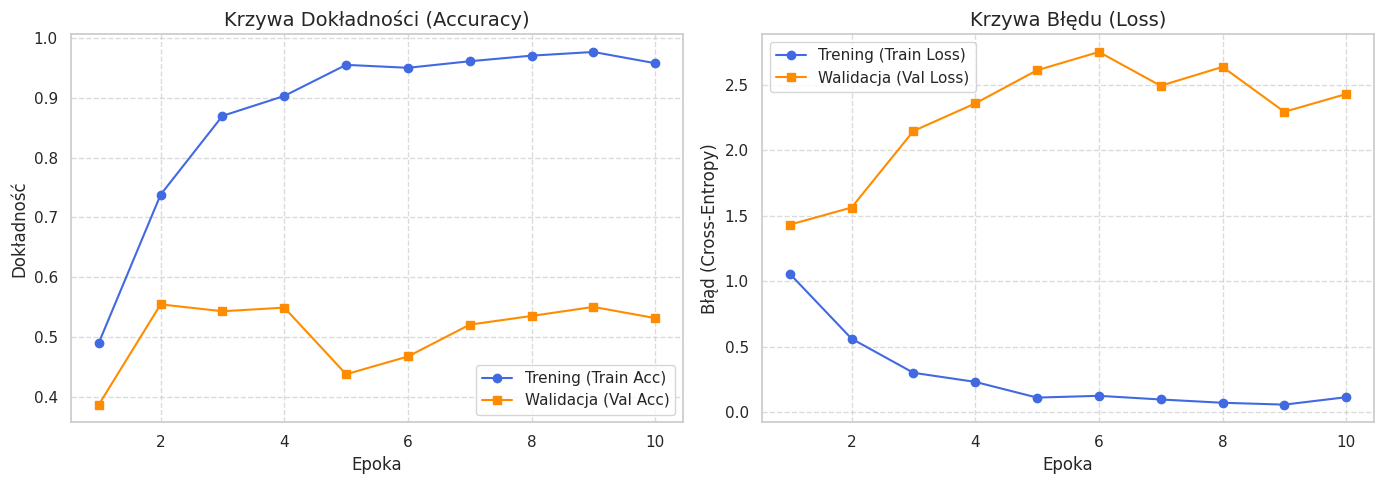

In [ ]:
epochs_range = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(14, 5))

# --- Wykres 1: Dokładność (Accuracy) ---
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_acc'], label='Trening (Train Acc)', marker='o', color='royalblue')
plt.plot(epochs_range, history['val_acc'], label='Walidacja (Val Acc)', marker='s', color='darkorange')
plt.title('Krzywa Dokładności (Accuracy)', fontsize=14)
plt.xlabel('Epoka', fontsize=12)
plt.ylabel('Dokładność', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)

# --- Wykres 2: Funkcja błędu (Loss) ---
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_loss'], label='Trening (Train Loss)', marker='o', color='royalblue')
plt.plot(epochs_range, history['val_loss'], label='Walidacja (Val Loss)', marker='s', color='darkorange')
plt.title('Krzywa Błędu (Loss)', fontsize=14)
plt.xlabel('Epoka', fontsize=12)
plt.ylabel('Błąd (Cross-Entropy)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()

plt.savefig('/content/learning_curves_resnet50.png', dpi=300)
plt.show()

Grad-Cam

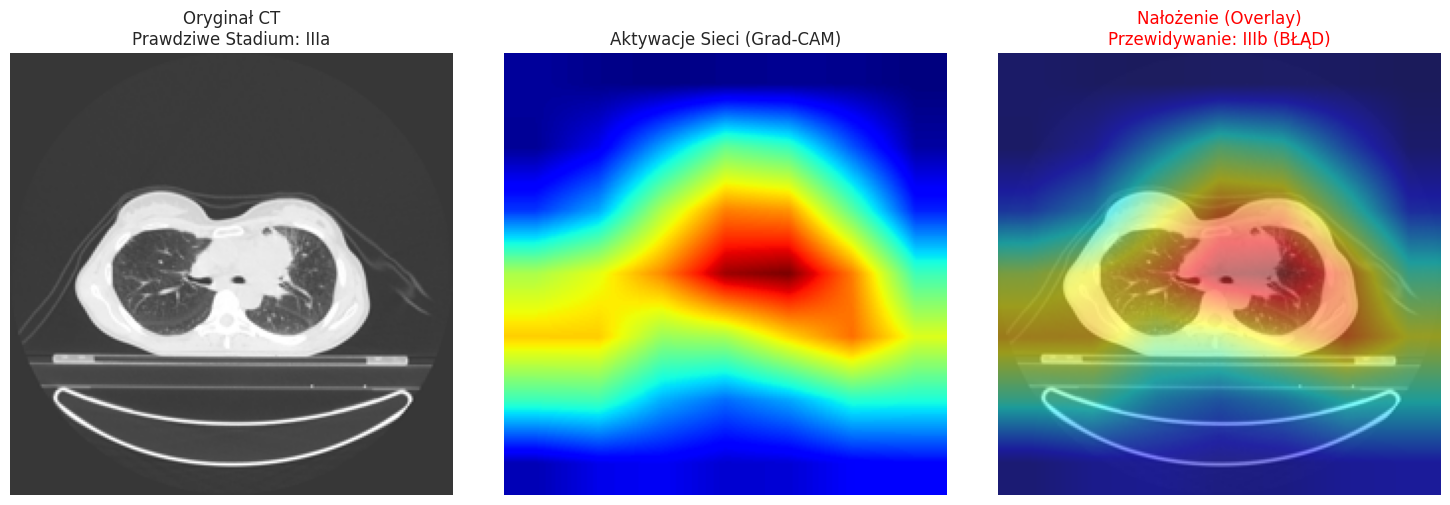

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Wczytanie wytrenowanego modelu
model = models.resnet50(weights=None)
model.fc = nn.Linear(model.fc.in_features, 4)
model.load_state_dict(torch.load('/content/best_resnet50_model.pth'))
model = model.to(device)
model.eval()

target_layers = [model.layer4[-1]]

# Losowanie obrazu testowego
df_test = pd.read_csv('/content/dataset/test.csv')
sample_row = df_test.iloc[random.randint(0, len(df_test) - 1)]

img_path = sample_row['image_path'].replace('\\', '/')
full_img_path = os.path.join('/content/dataset/data_2d_full_slices', os.path.basename(img_path))

actual_label = sample_row['label']
actual_stage = sample_row['original_stage']
stage_dict = {0: 'I', 1: 'II', 2: 'IIIa', 3: 'IIIb'}

# Preprocessing
rgb_img_pil = Image.open(full_img_path).convert('RGB').resize((224, 224))
rgb_img_float = np.float32(rgb_img_pil) / 255.0

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
input_tensor = transform(rgb_img_pil).unsqueeze(0).to(device)

# Predykcja
with torch.no_grad():
    output = model(input_tensor)
    predicted_label = torch.argmax(output, dim=1).item()
    predicted_stage = stage_dict[predicted_label]

# Generowanie mapy ciepła Grad-CAM
cam = GradCAM(model=model, target_layers=target_layers)
targets = [ClassifierOutputTarget(predicted_label)]

grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]
visualization = show_cam_on_image(rgb_img_float, grayscale_cam, use_rgb=True)

# Wyświetlanie wyników
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(rgb_img_pil, cmap='gray')
plt.title(f'Oryginał CT\nPrawdziwe Stadium: {actual_stage}', fontsize=12)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(grayscale_cam, cmap='jet')
plt.title('Aktywacje Sieci (Grad-CAM)', fontsize=12)
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(visualization)

color = 'green' if actual_label == predicted_label else 'red'
wynik = "SUKCES" if actual_label == predicted_label else "BŁĄD"

plt.title(f'Nałożenie (Overlay)\nPrzewidywanie: {predicted_stage} ({wynik})', fontsize=12, color=color)
plt.axis('off')

plt.tight_layout()
plt.show()